In [1]:
import sys
import sqlite3
import os

# Kiểm tra đúng venv chưa
print("Python:", sys.executable)

# Kiểm tra SQLite kết nối được
db_path = '../data/raw/portfolio.db'
conn = sqlite3.connect(db_path)
cursor = conn.execute("SELECT Ticker, COUNT(*) as rows FROM Stock_Prices GROUP BY Ticker")
print("\nData in DB:")
for row in cursor.fetchall():
    print(f"  {row[0]}: {row[1]:,} rows")
conn.close()
print("\n✅ venv + SQLite OK")

Python: D:\Projects\vn-portfolio-optimizer\venv\Scripts\python.exe

Data in DB:
  BID: 1,306 rows
  CTG: 1,306 rows
  FPT: 1,306 rows
  GAS: 1,306 rows
  HPG: 1,306 rows
  MWG: 665 rows
  TCB: 1,303 rows
  VCB: 1,306 rows
  VIC: 1,306 rows
  VNM: 665 rows

✅ venv + SQLite OK


In [2]:
# vnstock phiên bản cũ hơn, API khác
import subprocess
subprocess.run(['pip', 'install', 'vnstock'], capture_output=True)

from vnstock import stock_historical_data
df = stock_historical_data('VNM', '2024-01-01', '2024-01-31', '1D', 'stock')
print(df.head(10))
print("Shape:", df.shape)

ImportError: cannot import name 'stock_historical_data' from 'vnstock' (D:\Projects\vn-portfolio-optimizer\venv\Lib\site-packages\vnstock\__init__.py)

In [3]:
import vnstock
print(dir(vnstock))

['Company', 'EXCHANGES', 'Finance', 'Fund', 'INDEX_GROUPS', 'INDICES_INFO', 'INDICES_MAP', 'Listing', 'Quote', 'SECTOR_IDS', 'Trading', 'Vnstock', '_Vnstock', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_ensure_explorer_modules_loaded', '_ensure_vnai_initialized', '_explorer_modules_loaded', '_get_vnstock', '_vnai_initialized', 'api', 'base', 'change_api_key', 'check_status', 'config', 'connector', 'constants', 'core', 'explorer', 'register_user', 'update_notice', 'vnai']


In [4]:
import requests
import pandas as pd

def fetch_vndirect(ticker, start, end):
    url = "https://finfo-api.vndirect.com.vn/v4/stock_prices"
    params = {
        "sort": "date",
        "q": f"code:{ticker}~date:gte:{start}~date:lte:{end}",
        "fields": "date,open,high,low,close,nmVolume",
        "size": 100
    }
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, params=params, headers=headers, timeout=10)
    print("Status:", r.status_code)
    if r.status_code == 200:
        data = r.json()
        return pd.DataFrame(data.get('data', []))
    return pd.DataFrame()

df = fetch_vndirect('VCB', '2024-01-01', '2024-01-31')
print(df.head(10))
print("Shape:", df.shape)

ConnectTimeout: HTTPSConnectionPool(host='finfo-api.vndirect.com.vn', port=443): Max retries exceeded with url: /v4/stock_prices?sort=date&q=code%3AVCB~date%3Agte%3A2024-01-01~date%3Alte%3A2024-01-31&fields=date%2Copen%2Chigh%2Clow%2Cclose%2CnmVolume&size=100 (Caused by ConnectTimeoutError(<HTTPSConnection(host='finfo-api.vndirect.com.vn', port=443) at 0x2773a6f6e90>, 'Connection to finfo-api.vndirect.com.vn timed out. (connect timeout=10)'))

In [5]:
import requests
import pandas as pd
from datetime import datetime

def fetch_tcbs(ticker, start, end):
    start_ts = int(datetime.strptime(start, '%Y-%m-%d').timestamp())
    end_ts   = int(datetime.strptime(end,   '%Y-%m-%d').timestamp())
    url = f"https://apipubaws.tcbs.com.vn/stock-insight/v1/stock/bars-long-term"
    params = {
        "ticker": ticker,
        "type": "stock",
        "resolution": "D",
        "from": start_ts,
        "to": end_ts
    }
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Referer": "https://tcinvest.tcbs.com.vn/"
    }
    r = requests.get(url, params=params, headers=headers, timeout=10)
    print("Status:", r.status_code)
    if r.status_code == 200:
        data = r.json()
        df = pd.DataFrame(data.get('data', []))
        return df
    return pd.DataFrame()

df = fetch_tcbs('VCB', '2024-01-01', '2024-01-31')
print(df.head(10))
print("Columns:", df.columns.tolist() if not df.empty else "empty")


Status: 404
Empty DataFrame
Columns: []
Index: []
Columns: empty


In [6]:
import requests

# Test xem máy có ra được internet không
urls = [
    "https://apipubaws.tcbs.com.vn",
    "https://finance.vietstock.vn",
    "https://www.google.com",
]

for url in urls:
    try:
        r = requests.get(url, timeout=5)
        print(f"✅ {url} → {r.status_code}")
    except Exception as e:
        print(f"❌ {url} → {type(e).__name__}: {str(e)[:60]}")

✅ https://apipubaws.tcbs.com.vn → 404
✅ https://finance.vietstock.vn → 403
✅ https://www.google.com → 200


In [7]:
import requests
import pandas as pd
from datetime import datetime

def test_tcbs(url, ticker='VCB', start='2024-01-01', end='2024-01-31'):
    start_ts = int(datetime.strptime(start, '%Y-%m-%d').timestamp())
    end_ts   = int(datetime.strptime(end,   '%Y-%m-%d').timestamp())
    headers  = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "Referer": "https://tcinvest.tcbs.com.vn/",
        "Accept": "application/json",
    }
    params = {"ticker": ticker, "type": "stock", "resolution": "D",
              "from": start_ts, "to": end_ts}
    try:
        r = requests.get(url, params=params, headers=headers, timeout=10)
        print(f"  {r.status_code} → {url}")
        if r.status_code == 200:
            print("  ✅ Response:", str(r.json())[:200])
        else:
            print("  Response:", r.text[:100])
    except Exception as e:
        print(f"  ❌ {type(e).__name__}: {str(e)[:60]}")

endpoints = [
    "https://apipubaws.tcbs.com.vn/stock-insight/v1/stock/bars-long-term",
    "https://apipubaws.tcbs

SyntaxError: unterminated string literal (detected at line 27) (2047277474.py, line 27)

In [8]:
import requests
import pandas as pd
from datetime import datetime

start_ts = int(datetime.strptime('2024-01-01', '%Y-%m-%d').timestamp())
end_ts   = int(datetime.strptime('2024-01-31', '%Y-%m-%d').timestamp())

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Referer": "https://tcinvest.tcbs.com.vn/",
    "Accept": "application/json",
}

params = {
    "ticker": "VCB",
    "type": "stock",
    "resolution": "D",
    "from": start_ts,
    "to": end_ts
}

base = "https://apipubaws.tcbs.com.vn/stock-insight"

endpoints = [
    base + "/v1/stock/bars-long-term",
    base + "/v2/stock/bars-long-term",
    base + "/v1/stock/bars",
    base + "/v2/stock/bars",
    base + "/v1/stock/price-histories",
]

for ep in endpoints:
    try:
        r = requests.get(ep, params=params, headers=headers, timeout=10)
        preview = str(r.text[:80]) if r.status_code != 200 else "✅ OK"
        print(f"{r.status_code} | {ep.split('insight')[1]} | {preview}")
    except Exception as e:
        print(f"ERR | {ep.split('insight')[1]} | {type(e).__name__}")

404 | /v1/stock/bars-long-term | {"status":404,"message":"Service not found"}
404 | /v2/stock/bars-long-term | {"status":404,"message":"Service not found"}
404 | /v1/stock/bars | {"status":404,"message":"Service not found"}
404 | /v2/stock/bars | {"status":404,"message":"Service not found"}
404 | /v1/stock/price-histories | {"status":404,"message":"Service not found"}


In [9]:
import requests
import pandas as pd
from datetime import datetime

start_ts = int(datetime.strptime('2024-01-01', '%Y-%m-%d').timestamp())
end_ts   = int(datetime.strptime('2024-01-31', '%Y-%m-%d').timestamp())

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Referer": "https://tcinvest.tcbs.com.vn/",
    "Accept": "application/json",
}

# TCBS endpoints mới nhất 2024-2025
tests = [
    {
        "name": "TCBS v2 chart",
        "url": "https://apipubaws.tcbs.com.vn/stock-insight/v2/stock/chart",
        "params": {"ticker":"VCB","type":"stock","resolution":"D","from":start_ts,"to":end_ts}
    },
    {
        "name": "TCBS trading",
        "url": "https://apipubaws.tcbs.com.vn/stock-insight/v1/stock/trading-to-invest",
        "params": {"ticker":"VCB","type":"stock","resolution":"D","from":start_ts,"to":end_ts}
    },
    {
        "name": "TCBS history new",
        "url": "https://apipubaws.tcbs.com.vn/stock-insight/v1/stock/history",
        "params": {"ticker":"VCB","type":"stock","resolution":"D","from":start_ts,"to":end_ts}
    },
    {
        "name": "SSI iboard",
        "url": "https://iboard-query.ssi.com.vn/v2/stock/historical-price",
        "params": {"symbol":"VCB","fromDate":"2024-01-01","toDate":"2024-01-31","offset":0,"pageSize":50,"orderBy":"TradingDate","order":"asc"}
    },
    {
        "name": "Fireant",
        "url": "https://restv2.fireant.vn/symbols/VCB/historical-quotes",
        "params": {"startDate":"2024-01-01","endDate":"2024-01-31","offset":0,"limit":50}
    },
]

for t in tests:
    try:
        r = requests.get(t["url"], params=t["params"], headers=headers, timeout=10)
        if r.status_code == 200:
            data = r.json()
            print(f"✅ {t['name']} → keys: {list(data.keys()) if isinstance(data, dict) else type(data)}")
            print(f"   Preview: {str(data)[:150]}")
        else:
            print(f"❌ {t['name']} → {r.status_code}: {r.text[:80]}")
    except Exception as e:
        print(f"❌ {t['name']} → {type(e).__name__}: {str(e)[:60]}")

❌ TCBS v2 chart → 404: {"status":404,"message":"Service not found"}
❌ TCBS trading → 404: {"status":404,"message":"Service not found"}
❌ TCBS history new → 404: {"status":404,"message":"Service not found"}
❌ SSI iboard → 404: {"code":"ERR_SQ_0001","message":"Request not found","error":"Request not found",
❌ Fireant → 401: {"message":"Authorization has been denied for this request."}


In [10]:
try:
    from vnstock3.explorer.tcbs.quote import Quote as TCBSQuote
    q = TCBSQuote(symbol='VCB', show_log=False)
    df = q.history(start='2024-01-01', end='2024-01-31', interval='1D')
    print("✅ TCBSQuote works:")
    print(df.head())
    print("Columns:", df.columns.tolist())
except Exception as e:
    print(f"❌ TCBSQuote: {type(e).__name__}: {str(e)[:200]}")

try:
    from vnstock3.explorer.vci.quote import Quote as VCIQuote
    q = VCIQuote(symbol='VCB', show_log=False)
    df = q.history(start='2024-01-01', end='2024-01-31', interval='1D')
    print("\n✅ VCIQuote works:")
    print(df.head())
    print("Columns:", df.columns.tolist())
except Exception as e:
    print(f"❌ VCIQuote: {type(e).__name__}: {str(e)[:200]}")
    

Thư viện `vnstock3` đã được hợp nhất với tên gọi `vnstock`. Phiên bản mới nhất 3.5.0 đã có mặt.Vui lòng chuyển đổi gói thư viện thành `vnstock` để luôn nhận bản cập nhật với câu lệnh : `pip install vnstock --upgrade`.
Lịch sử phiên bản: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban
Phiên bản hiện tại 3.2.1

❌ TCBSQuote: ConnectionError: Tải dữ liệu không thành công: 404 - Not Found

✅ VCIQuote works:
        time   open   high    low  close   volume
0 2024-01-02  55.05  55.52  54.59  55.45  1788420
1 2024-01-03  55.45  56.12  54.99  56.12  1374590
2 2024-01-04  56.12  57.24  55.78  57.04  2660779
3 2024-01-05  57.04  57.24  56.91  57.24  1181807
4 2024-01-08  57.31  57.64  57.31  57.64  1611721
Columns: ['time', 'open', 'high', 'low', 'close', 'volume']


In [11]:
from vnstock import Vnstock

stock = Vnstock().stock(symbol='VCB', source='TCBS')
df = stock.quote.history(start='2024-01-01', end='2024-01-31', interval='1D')
print(df.head(10))
print("\nShape:", df.shape)

ValueError: Supported sources: KBS, VCI, MSN, FMP. Got: TCBS

In [12]:
from vnstock import Vnstock

stock = Vnstock().stock(symbol='VCB', source='VCI')
df = stock.quote.history(start='2024-01-01', end='2024-01-31', interval='1D')
print(df.head(10))
print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())

        time   open   high    low  close   volume
0 2023-12-27  55.05  55.25  54.79  54.92   900989
1 2023-12-28  54.92  55.19  54.72  54.99   704577
2 2023-12-29  55.45  55.72  53.33  53.33  1623585
3 2024-01-02  55.05  55.52  54.59  55.45  1788420
4 2024-01-03  55.45  56.12  54.99  56.12  1374590
5 2024-01-04  56.12  57.24  55.78  57.04  2660779
6 2024-01-05  57.04  57.24  56.91  57.24  1181807
7 2024-01-08  57.31  57.64  57.31  57.64  1611721
8 2024-01-09  57.64  58.37  57.64  58.31  1928985
9 2024-01-10  58.31  59.44  57.91  59.44  1800328

Shape: (25, 6)
Columns: ['time', 'open', 'high', 'low', 'close', 'volume']


In [13]:
print("\nClose price range:")
print(f"  Min: {df['close'].min():,.0f}")
print(f"  Max: {df['close'].max():,.0f}")
print(f"  Mean: {df['close'].mean():,.0f}")
print("\nExpected VCB Jan 2024: ~85,000–90,000 VND")


Close price range:
  Min: 53
  Max: 61
  Mean: 59

Expected VCB Jan 2024: ~85,000–90,000 VND


In [14]:
from vnstock import Vnstock
import pandas as pd

# Test đủ 10 mã
tickers = ['VCB', 'VNM', 'HPG', 'FPT', 'MWG', 'VIC', 'GAS', 'BID', 'CTG', 'TCB']

results = []
for t in tickers:
    try:
        stock = Vnstock().stock(symbol=t, source='VCI')
        df = stock.quote.history(start='2024-01-01', end='2024-01-31', interval='1D')
        results.append({
            'Ticker': t,
            'Rows': len(df),
            'Close_min': df['close'].min(),
            'Close_max': df['close'].max(),
            'Status': '✅'
        })
    except Exception as e:
        results.append({
            'Ticker': t,
            'Rows': 0,
            'Close_min': None,
            'Close_max': None,
            'Status': f'❌ {type(e).__name__}'
        })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))

Ticker  Rows  Close_min  Close_max Status
   VCB    25      53.33      61.49      ✅
   VNM    25      58.42      60.25      ✅
   HPG    25      20.53      21.48      ✅
   FPT    25      69.31      71.28      ✅
   MWG    25      40.98      45.14      ✅
   VIC    25      21.25      22.30      ✅
   GAS    25      64.33      66.13      ✅
   BID    25      34.90      40.74      ✅
   CTG    25      18.42      22.39      ✅
   TCB    25      14.57      16.75      ✅


In [15]:
import pandas as pd

# ── Source 1: vnstock VCI ─────────────────────────────────────────
from vnstock import Vnstock

stock = Vnstock().stock(symbol='VCB', source='VCI')
df1 = stock.quote.history(start='2024-01-01', end='2024-01-31', interval='1D')
print("=== vnstock VCI ===")
print(df1.head(5).to_string())
print(f"Columns : {df1.columns.tolist()}")
print(f"Rows    : {len(df1)}")
print(f"Close   : {df1['close'].min()} – {df1['close'].max()}")
print(f"Dtypes  :\n{df1.dtypes}\n")

# ── Source 2: vnstock3 VCI ────────────────────────────────────────
from vnstock3.explorer.vci.quote import Quote as VCIQuote

q = VCIQuote(symbol='VCB', show_log=False)
df2 = q.history(start='2024-01-01', end='2024-01-31', interval='1D')
print("=== vnstock3 VCI ===")
print(df2.head(5).to_string())
print(f"Columns : {df2.columns.tolist()}")
print(f"Rows    : {len(df2)}")
print(f"Close   : {df2['close'].min()} – {df2['close'].max()}")
print(f"Dtypes  :\n{df2.dtypes}\n")

# ── So sánh giá từng ngày ─────────────────────────────────────────
df1_cmp = df1[['time','close']].copy()
df1_cmp.columns = ['date','close_vnstock']

df2_cmp = df2[['time','close']].copy()
df2_cmp.columns = ['date','close_vnstock3']

df1_cmp['date'] = pd.to_datetime(df1_cmp['date']).dt.strftime('%Y-%m-%d')
df2_cmp['date'] = pd.to_datetime(df2_cmp['date']).dt.strftime('%Y-%m-%d')

merged = df1_cmp.merge(df2_cmp, on='date', how='outer').sort_values('date')
merged['diff'] = merged['close_vnstock'] - merged['close_vnstock3']
print("=== Price comparison per day ===")
print(merged.to_string(index=False))
print(f"\nMax difference: {merged['diff'].abs().max()}")

=== vnstock VCI ===
        time   open   high    low  close   volume
0 2023-12-27  55.05  55.25  54.79  54.92   900989
1 2023-12-28  54.92  55.19  54.72  54.99   704577
2 2023-12-29  55.45  55.72  53.33  53.33  1623585
3 2024-01-02  55.05  55.52  54.59  55.45  1788420
4 2024-01-03  55.45  56.12  54.99  56.12  1374590
Columns : ['time', 'open', 'high', 'low', 'close', 'volume']
Rows    : 25
Close   : 53.33 – 61.49
Dtypes  :
time      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

=== vnstock3 VCI ===
        time   open   high    low  close   volume
0 2024-01-02  55.05  55.52  54.59  55.45  1788420
1 2024-01-03  55.45  56.12  54.99  56.12  1374590
2 2024-01-04  56.12  57.24  55.78  57.04  2660779
3 2024-01-05  57.04  57.24  56.91  57.24  1181807
4 2024-01-08  57.31  57.64  57.31  57.64  1611721
Columns : ['time', 'open', 'high', 'low', 'close', 'volume']
Rows    : 22
Close   : 55

In [16]:
import sys, importlib
sys.path.append('../src')
import data_loader
importlib.reload(data_loader)
from data_loader import update_db, load_from_db, get_db_summary

# Xóa data cũ (yfinance), fetch lại bằng VCI
update_db(
    start='2021-01-01',
    replace=True
)

✅ Table Stock_Prices ready
🗑️  Cleared existing rows for: ['VCB', 'BID', 'CTG', 'TCB', 'MBB', 'VPB', 'ACB', 'HDB', 'STB', 'SHB', 'LPB', 'OCB', 'MSB', 'EIB', 'VIC', 'VHM', 'VRE', 'FPT', 'VNM', 'MWG', 'SAB', 'GAS', 'PLX', 'HPG', 'BVH', 'HVN', 'GMD', 'PDR', 'KDC', 'REE']

📥 Fetching 30 tickers | 2021-01-01 → 2026-04-05
   Source: vnstock3 VCI (fallback: yfinance)

  ✅ VCB   → 1,307 rows
  ✅ BID   → 1,307 rows
  ✅ CTG   → 1,307 rows
  ✅ TCB   → 1,307 rows
  ✅ MBB   → 1,307 rows
  ✅ VPB   → 1,307 rows
  ✅ ACB   → 1,307 rows
  ✅ HDB   → 1,307 rows
  ✅ STB   → 1,307 rows
  ✅ SHB   → 1,304 rows
  ✅ LPB   → 1,307 rows
  ✅ OCB   → 1,289 rows
  ✅ MSB   → 1,307 rows
  ✅ EIB   → 1,307 rows
  ✅ VIC   → 1,307 rows
  ✅ VHM   → 1,307 rows
  ✅ VRE   → 1,307 rows
  ✅ FPT   → 1,307 rows
  ✅ VNM   → 1,307 rows
  ✅ MWG   → 1,307 rows

⚠️ 
⚠️  GIỚI HẠN API ĐÃ ĐẠT TỐI ĐA (Rate Limit Exceeded)

📌 Bạn đã đạt giới hạn tối đa số lượt yêu cầu API trong 1 phút (minute).
   (You have reached the maximum API request 

SystemExit: Rate limit exceeded. 
============================================================
⚠️  GIỚI HẠN API ĐÃ ĐẠT TỐI ĐA (Rate Limit Exceeded)
============================================================

📌 Bạn đã đạt giới hạn tối đa số lượt yêu cầu API trong 1 phút (minute).
   (You have reached the maximum API request limit for this period)

📊 Chi tiết (Details):
   • Gói hiện tại: Khách (Guest)
   • Giới hạn: 20 requests/phút
   • Đã sử dụng: 20/20
   • Chờ 9 giây để tiếp tục (Wait to retry)

💡 Giải pháp (Solutions):
   1️⃣ Chờ 9 giây rồi thử lại
      (Wait and retry)
   2️⃣ Tham gia gói thành viên tài trợ để sử dụng không bị gián đoạn
      (Join sponsor membership for uninterrupted access)

🚀 Nâng cấp (Upgrade):
   • Phiên bản cộng đồng (60 request/phút - Community):
     Đăng ký API key miễn phí: https://vnstocks.com/login
   • Gói thành viên tài trợ (180-600 request/phút - Sponsor):
     Tham gia: https://vnstocks.com/insiders-program
     Sau khi tham gia tài trợ, cài bộ 

To exit: use 'exit', 'quit', or Ctrl-D.


In [17]:
import sys, importlib
sys.path.append('../src')
import data_loader
importlib.reload(data_loader)
from data_loader import update_db

# Chỉ fetch 10 mã còn thiếu
remaining = ['SAB', 'GAS', 'PLX', 'HPG', 'BVH', 'HVN', 'GMD', 'PDR', 'KDC', 'REE']
update_db(tickers=remaining, start='2021-01-01', replace=False)

✅ Table Stock_Prices ready
📥 Fetching 10 tickers | 2021-01-01 → 2026-04-05
   Source: vnstock3 VCI (fallback: yfinance)

  ✅ SAB   → 1,307 rows
  ✅ GAS   → 1,307 rows
  ✅ PLX   → 1,307 rows
  ✅ HPG   → 1,307 rows
  ✅ BVH   → 1,307 rows
  ✅ HVN   → 1,307 rows
  ✅ GMD   → 1,307 rows
  ✅ PDR   → 1,307 rows
  ✅ KDC   → 1,307 rows
  ✅ REE   → 1,307 rows

✅ Done. Total new rows: 13,070

📊 DB Summary:
Ticker  rows start_date   end_date
   ACB  1307 2021-01-04 2026-04-03
   BID  1307 2021-01-04 2026-04-03
   BVH  1307 2021-01-04 2026-04-03
   CTG  1307 2021-01-04 2026-04-03
   EIB  1307 2021-01-04 2026-04-03
   FPT  1307 2021-01-04 2026-04-03
   GAS  1307 2021-01-04 2026-04-03
   GMD  1307 2021-01-04 2026-04-03
   HDB  1307 2021-01-04 2026-04-03
   HPG  1307 2021-01-04 2026-04-03
   HVN  1307 2021-01-04 2026-04-03
   KDC  1307 2021-01-04 2026-04-03
   LPB  1307 2021-01-04 2026-04-03
   MBB  1307 2021-01-04 2026-04-03
   MSB  1307 2021-01-04 2026-04-03
   MWG  1307 2021-01-04 2026-04-03
   OCB 

In [ ]:
import sqlite3
import pandas as pd
import sys
sys.path.append('../src')

# Query trực tiếp bằng SQL thuần
conn = sqlite3.connect('../data/raw/portfolio.db')

# Xem 10 ngày gần nhất của VCB
df_vcb = pd.read_sql_query('''
    SELECT Ticker, Date, Open, High, Low, Close, Volume
    FROM Stock_Prices
    WHERE Ticker = 'VCB'
    ORDER BY Date DESC
    LIMIT 10
''', conn)

conn.close()

print("=== VCB — 10 ngày gần nhất (giá x1000 VND) ===")
print(df_vcb.to_string(index=False))
print(f"\n👉 Vào CafeF hoặc Vietstock kiểm tra giá VCB cùng ngày")
print(f"   Ngày mới nhất trong DB: {df_vcb['Date'].iloc[0]}")


In [ ]:
import sqlite3

conn = sqlite3.connect('../data/raw/portfolio.db')
cursor = conn.execute("SELECT COUNT(*) FROM Stock_Prices")
print("Total rows:", cursor.fetchone()[0])
conn.close()

In [ ]:
import sqlite3

conn = sqlite3.connect('../data/raw/portfolio.db')
cursor = conn.execute("SELECT COUNT(*) FROM Stock_Prices")
print("Total rows:", cursor.fetchone()[0])
conn.close()

In [ ]:
import os

# Xem notebook đang chạy từ thư mục nào
print("Current working directory:", os.getcwd())

# Xem file DB có tồn tại không
paths_to_check = [
    '../data/raw/portfolio.db',
    'data/raw/portfolio.db',
    'D:/Projects/vn-portfolio-optimizer/data/raw/portfolio.db'
]

for p in paths_to_check:
    exists = os.path.exists(p)
    print(f"{'✅' if exists else '❌'} {p}")

In [1]:
import os
print("Working dir:", os.getcwd())

Working dir: D:\Projects\vn-portfolio-optimizer\notebooks


In [2]:
import sqlite3

conn = sqlite3.connect('../data/raw/portfolio.db')
cursor = conn.execute("SELECT COUNT(*) FROM Stock_Prices")
print("Total rows:", cursor.fetchone()[0])
conn.close()

Total rows: 39189


In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../data/raw/portfolio.db')
df_vcb = pd.read_sql_query('''
    SELECT Ticker, Date, Open, High, Low, Close, Volume
    FROM Stock_Prices
    WHERE Ticker = 'VCB'
    ORDER BY Date DESC
    LIMIT 10
''', conn)
conn.close()

print("=== VCB — 10 ngày gần nhất (đơn vị: nghìn VND) ===")
print(df_vcb.to_string(index=False))

=== VCB — 10 ngày gần nhất (đơn vị: nghìn VND) ===
Ticker       Date  Open  High  Low  Close  Volume
   VCB 2026-04-03  58.3  58.5 57.7   57.7 5919600
   VCB 2026-04-02  58.7  58.8 58.1   58.2 5664500
   VCB 2026-04-01  58.9  59.2 58.5   59.0 8254700
   VCB 2026-03-31  58.2  58.9 58.0   58.1 5481100
   VCB 2026-03-30  57.9  58.5 57.8   58.0 5546000
   VCB 2026-03-27  58.0  59.0 57.9   58.8 6135900
   VCB 2026-03-26  58.5  58.6 57.5   57.9 6217800
   VCB 2026-03-25  58.8  59.1 58.0   58.4 8558200
   VCB 2026-03-24  59.0  59.0 58.0   58.2 4332300
   VCB 2026-03-23  57.8  58.3 56.5   57.6 9648600


In [4]:
import sys
sys.path.append('../src')
from data_loader import load_from_db

tickers = ['VCB','VNM','HPG','FPT','OCB','SHB','HVN','PDR']
print(f"{'Ticker':<8} {'Rows':>6} {'Close Min':>10} {'Close Max':>10} {'Nulls':>6}")
print("-" * 45)
for t in tickers:
    df = load_from_db(t, '2021-01-01', '2026-04-05')
    nulls = df.isnull().sum().sum()
    print(f"{t:<8} {len(df):>6,} {df['Close'].min():>10.1f} {df['Close'].max():>10.1f} {nulls:>6}")

Ticker     Rows  Close Min  Close Max  Nulls
---------------------------------------------
VCB       1,307       34.9       76.0      0
VNM       1,307       48.0       88.5      0
HPG       1,307        9.2       33.2      0
FPT       1,307       25.3      131.7      0
OCB       1,289        6.0       14.9      0
SHB       1,304        4.7       18.8      0
HVN       1,307        6.8       38.2      0
PDR       1,307        8.4       60.8      0


In [5]:
import sys
sys.path.append('../src')
from data_loader import load_from_db, VN30_TICKERS

print(f"{'Ticker':<8} {'Rows':>6} {'Close Min':>10} {'Close Max':>10} {'Nulls':>6}")
print("-" * 45)

all_ok = True
for t in VN30_TICKERS:
    df = load_from_db(t, '2021-01-01', '2026-04-05')
    nulls = df.isnull().sum().sum()
    status = '✅' if len(df) > 1200 and nulls == 0 else '⚠️ '
    if status == '⚠️ ':
        all_ok = False
    print(f"{status} {t:<6} {len(df):>6,} {df['Close'].min():>10.1f} {df['Close'].max():>10.1f} {nulls:>6}")

print("-" * 45)
print(f"\n{'✅ All 30 tickers OK' if all_ok else '⚠️  Some tickers need attention'}")

Ticker     Rows  Close Min  Close Max  Nulls
---------------------------------------------
✅ VCB     1,307       34.9       76.0      0
✅ BID     1,307       20.7       55.0      0
✅ CTG     1,307       12.2       41.5      0
✅ TCB     1,307        9.8       41.3      0
✅ MBB     1,307        7.4       29.0      0
✅ VPB     1,307        9.7       38.6      0
✅ ACB     1,307        9.6       29.4      0
✅ HDB     1,307        7.1       29.7      0
✅ STB     1,307       14.8       67.8      0
✅ SHB     1,304        4.7       18.8      0
✅ LPB     1,307        5.0       53.9      0
✅ OCB     1,289        6.0       14.9      0
✅ MSB     1,307        6.1       15.4      0
✅ EIB     1,307       10.9       31.1      0
✅ VIC     1,307       19.9      179.0      0
✅ VHM     1,307       34.5      149.5      0
✅ VRE     1,307       16.1       43.4      0
✅ FPT     1,307       25.3      131.7      0
✅ VNM     1,307       48.0       88.5      0
✅ MWG     1,307       34.3       93.7      0
✅ SAB    

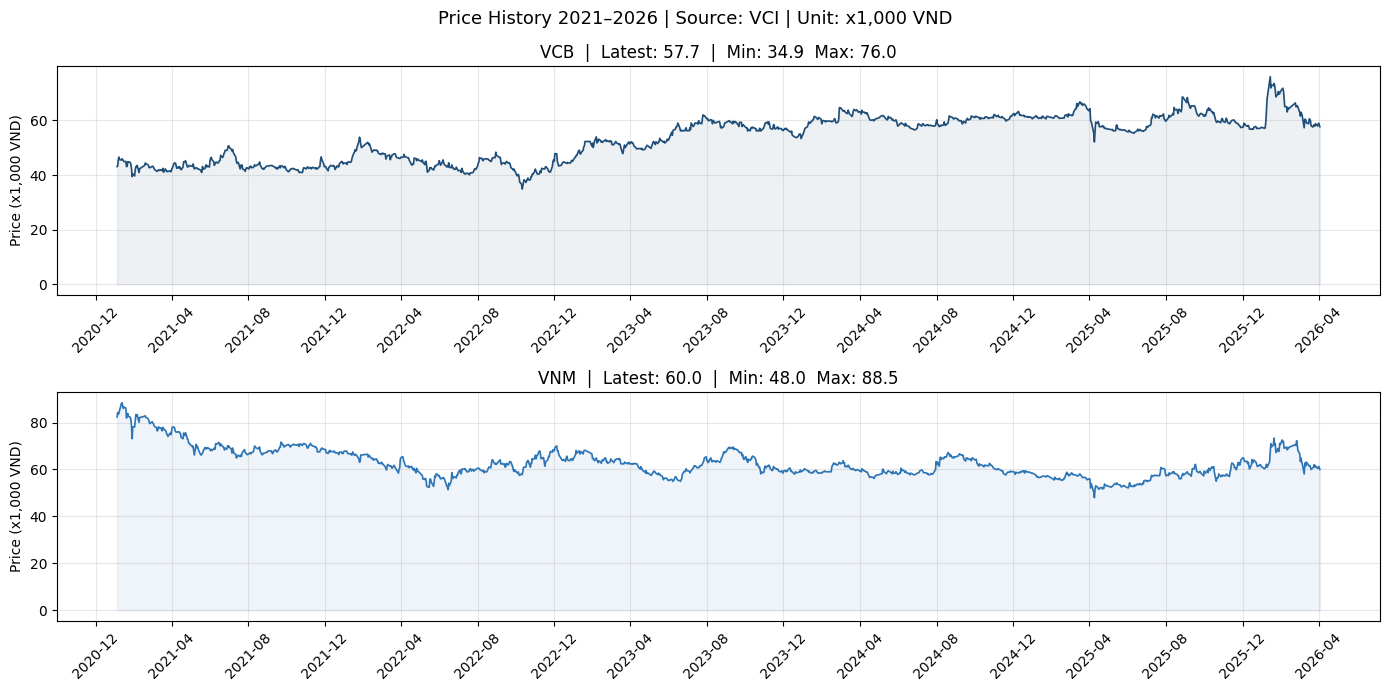

✅ Saved to reports/vcb_vnm_price_history.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from data_loader import load_from_db

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('Price History 2021–2026 | Source: VCI | Unit: x1,000 VND', fontsize=13)

for ax, ticker, color in zip(axes, ['VCB', 'VNM'], ['#1F4E79', '#2E75B6']):
    df = load_from_db(ticker, '2021-01-01', '2026-04-05')
    ax.plot(df.index, df['Close'], color=color, linewidth=1.2)
    ax.fill_between(df.index, df['Close'], alpha=0.08, color=color)
    ax.set_title(f'{ticker}  |  Latest: {df["Close"].iloc[-1]:.1f}  |  '
                 f'Min: {df["Close"].min():.1f}  Max: {df["Close"].max():.1f}')
    ax.set_ylabel('Price (x1,000 VND)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/vcb_vnm_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/vcb_vnm_price_history.png")